# wcc-sim: example usage and verification

End-to-end demo of **wcc_sim** — simulating Lazuli WCC images of a real Gaia DR3 field —
with checks that the astrometry, photometry, PSFs, noise, and saturation behave as expected.

**Requirements:** run with the `py313` conda env kernel (the only env with `wcc_etc` + `astroquery`
installed). The first run queries the Gaia archive once; results are cached in `gaia_cache/` so
re-runs are offline.

Pipeline under the hood: Gaia DR3 cone search → BP−RP → Pickles spectral type → normalized to
G mag in the Gaia DR3 G passband → count rates through the `wcc_etc` throughput model → PSF
placement (in-focus Airy or +1/+2-wave defocus Huygens) → photon/sky/dark/read noise →
full-well + ADC saturation → FITS.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

import wcc_etc
import wcc_sim
from wcc_sim import simulate_field

plt.style.use('gks')
TEAL, RED, AMBER = '#00798c', '#d1495b', '#edae49'

print(f'wcc_sim {wcc_sim.__version__} | wcc_etc {wcc_etc.__version__}')

wcc_sim 0.1.0 | wcc_etc 0.6.0


## 1. Simulate a field

One call renders one detector. We point at a Kepler-field location and simulate the full Sony
IMX455 array (9568×6380 px, 16.87 mas/px ≈ 2.7′ × 1.8′ on sky) in the `zwo:r` band, 90 s, in focus.

In [2]:
RA0, DEC0 = 291.0, 44.5   # deg, ICRS (Kepler field)
EXPTIME = 90.0             # s

field = simulate_field(
    ra=RA0, dec=DEC0, sensorfilter='zwo:r', focus=0,
    exptime=EXPTIME, seed=42, mag_limit=21.0,
    cache_dir='gaia_cache',
)

p = field.params
print(f"{p['n_sources']} Gaia sources (G <= {p['mag_limit']}), "
      f"{int(field.saturation_mask.sum())} saturated px")
print(f"plate scale {p['plate_scale_mas']:.2f} mas/px | sky {p['sky_e_s']:.3f} + "
      f"dark {p['dark_e_s']:.4f} e-/s/px | read noise {p['read_noise']:.2f} e- | "
      f"gain {p['gain']:.3f} e-/ADU")

100 Gaia sources (G <= 21.0), 168 saturated px
plate scale 16.87 mas/px | sky 0.014 + dark 0.0031 e-/s/px | read noise 3.04 e- | gain 0.261 e-/ADU


## 2. Full-frame image with the Gaia catalog overlaid

If the WCS and source placement are right, every injected star (orange circle = Gaia position
mapped through the image WCS) should sit on a point source.

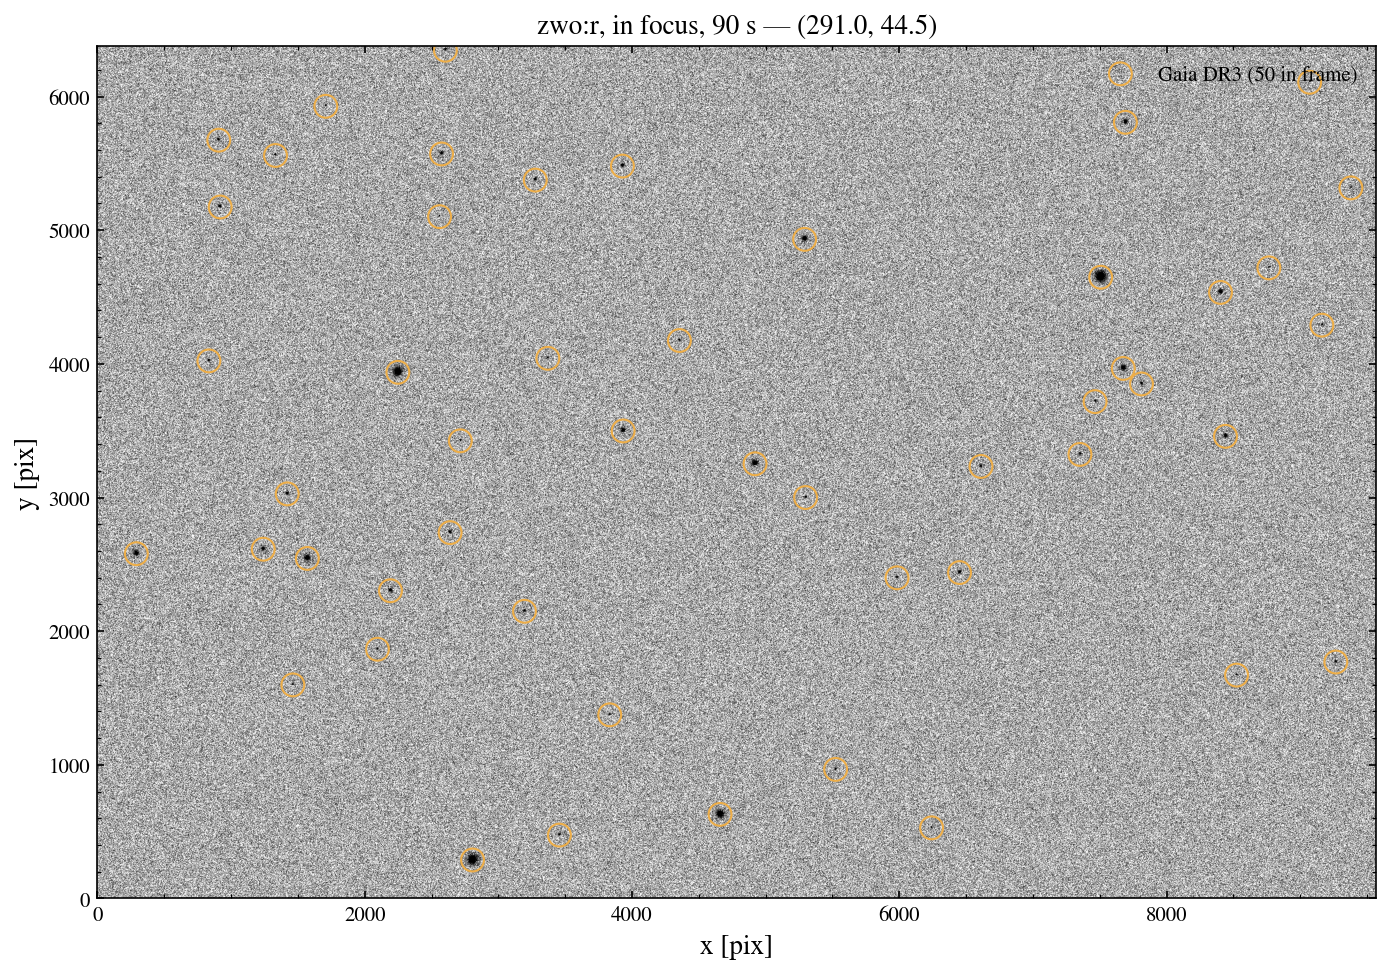

In [3]:
from astropy.visualization import simple_norm

img = field.image_adu
cat = field.catalog
inside = np.asarray(cat['in_image'], dtype=bool)

fig, ax = plt.subplots(figsize=(11, 7.5))
norm = simple_norm(img[::4, ::4], 'asinh', percent=99.8)
ax.imshow(img[::4, ::4], origin='lower', cmap='gray_r', norm=norm,
          extent=(0, img.shape[1], 0, img.shape[0]))
ax.scatter(cat['x'][inside], cat['y'][inside], s=120, facecolor='none',
           edgecolor=AMBER, lw=1.0, label=f'Gaia DR3 ({inside.sum()} in frame)')
ax.set_xlabel('x [pix]'); ax.set_ylabel('y [pix]')
ax.set_title(f'zwo:r, in focus, {EXPTIME:.0f} s — ({RA0}, {DEC0})')
ax.legend(loc='upper right')
plt.show()

## 3. The three PSF modes: in-focus, +1 wave, +2 waves defocus

We pick a bright, isolated, unsaturated star from the catalog and re-simulate a 600×600 px
subarray **centered on that star's RA/Dec** at each focus level — which also exercises the
pointing logic. The defocused PSFs are the Zemax Huygens models bundled with wcc-etc; note the
characteristic ring (centrally-depressed) structure.

In [4]:
from scipy.spatial import cKDTree

xy = np.c_[cat['x'], cat['y']]
tree = cKDTree(xy)
neigh = tree.query(xy, k=2)[0][:, 1]                  # distance to nearest neighbor [px]
sat = np.asarray(cat['saturated'], dtype=bool)
ok = inside & ~sat & (neigh > 180)                    # isolated: > 3 arcsec
star = cat[ok][np.argmin(cat['phot_g_mean_mag'][ok])]
print(f"star: Gaia DR3 {star['source_id']}  G={star['phot_g_mean_mag']:.2f}  "
      f"spt={star['spt']}  rate={star['rate_e_s']:.0f} e-/s")

fields_focus = {}
for foc in (0, 1, 2):
    fields_focus[foc] = simulate_field(
        ra=float(star['ra']), dec=float(star['dec']), sensorfilter='zwo:r',
        focus=foc, exptime=EXPTIME, seed=42, shape=(600, 600),
        cache_dir='gaia_cache',
    )
print('subarray sims done')

star: Gaia DR3 2126245588779207936  G=18.26  spt=G5V  rate=1914 e-/s


subarray sims done


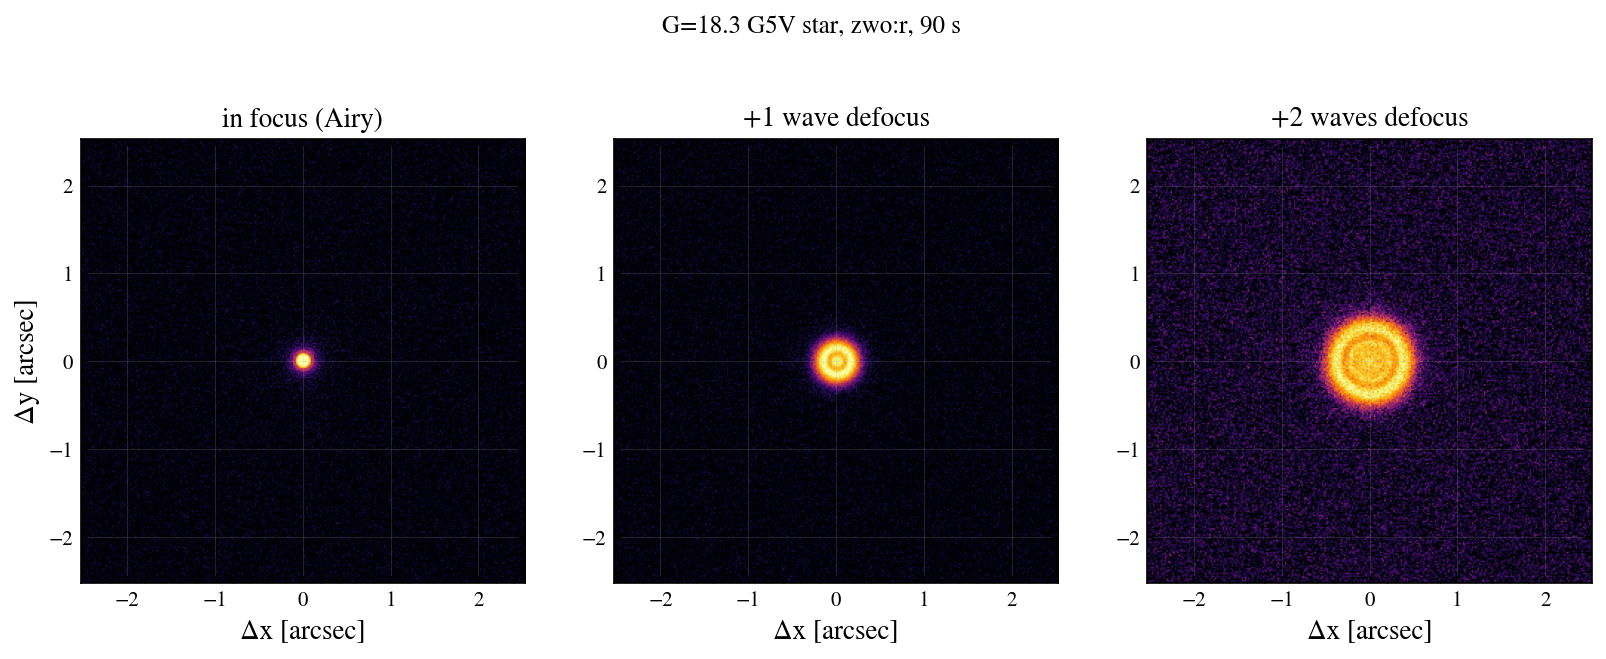

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
titles = ['in focus (Airy)', '+1 wave defocus', '+2 waves defocus']
for ax, foc, title in zip(axes, (0, 1, 2), titles):
    im = fields_focus[foc].image_adu
    cut = im[300 - 150:300 + 150, 300 - 150:300 + 150]
    norm = simple_norm(cut, 'asinh', percent=99.9)
    ax.imshow(cut, origin='lower', cmap='inferno', norm=norm,
              extent=(-150 * 16.87 / 1000, 150 * 16.87 / 1000,
                      -150 * 16.87 / 1000, 150 * 16.87 / 1000))
    ax.set_title(title)
    ax.set_xlabel('Δx [arcsec]')
axes[0].set_ylabel('Δy [arcsec]')
fig.suptitle(f"G={star['phot_g_mean_mag']:.1f} {star['spt']} star, zwo:r, {EXPTIME:.0f} s", y=1.02)
plt.show()

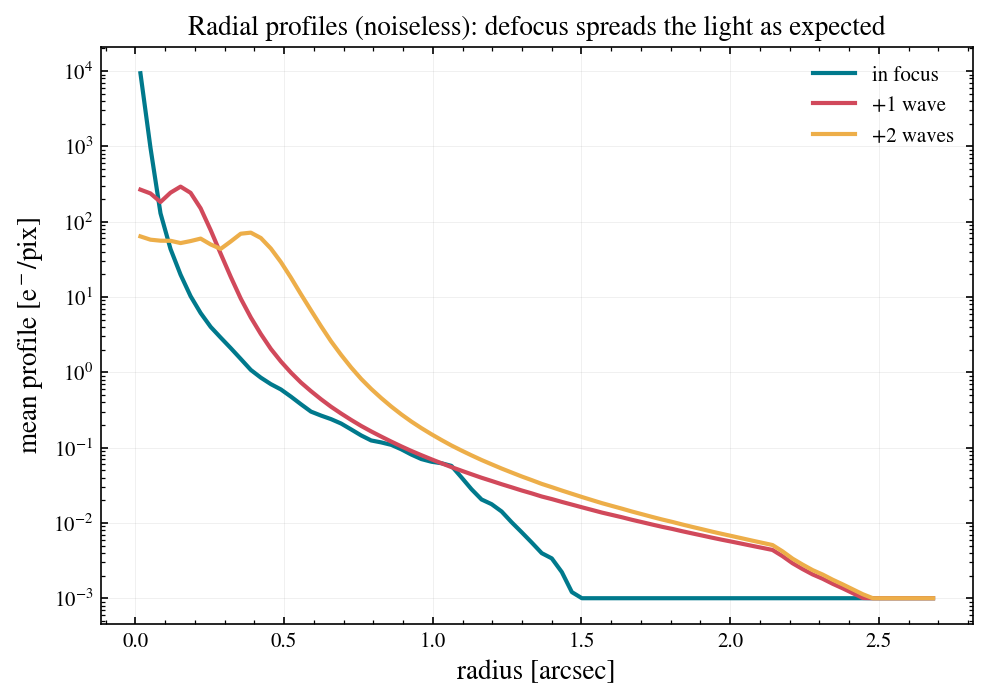

peak pixel: in-focus 14410 e- | +1w 310 e- (2.1%) | +2w 76 e- (0.5%)
PASS: peak ordering in-focus > +1w > +2w


In [6]:
def radial_profile(image, bg, r_max=160, n_bins=80):
    ny, nx = image.shape
    yy, xx = np.mgrid[:ny, :nx]
    r = np.hypot(xx - (nx - 1) / 2, yy - (ny - 1) / 2)
    bins = np.linspace(0, r_max, n_bins + 1)
    idx = np.digitize(r.ravel(), bins)
    prof = np.array([np.mean((image.ravel() - bg)[idx == i]) for i in range(1, n_bins + 1)])
    return 0.5 * (bins[1:] + bins[:-1]), prof

bg = (p['sky_e_s'] + p['dark_e_s']) * EXPTIME
fig, ax = plt.subplots(figsize=(7.5, 5))
for foc, col, lab in [(0, TEAL, 'in focus'), (1, RED, '+1 wave'), (2, AMBER, '+2 waves')]:
    r_pix, prof = radial_profile(fields_focus[foc].image_clean, bg)
    ax.semilogy(r_pix * 16.87 / 1000, np.clip(prof, 1e-3, None), color=col, label=lab)
ax.set_xlabel('radius [arcsec]'); ax.set_ylabel('mean profile [e$^-$/pix]')
ax.set_title('Radial profiles (noiseless): defocus spreads the light as expected')
ax.legend()
plt.show()

peak = {f: fields_focus[f].image_clean.max() - bg for f in (0, 1, 2)}
print(f"peak pixel: in-focus {peak[0]:.0f} e- | +1w {peak[1]:.0f} e- ({peak[1]/peak[0]:.1%}) "
      f"| +2w {peak[2]:.0f} e- ({peak[2]/peak[0]:.1%})")
assert peak[0] > peak[1] > peak[2], 'defocus must lower the peak'
print('PASS: peak ordering in-focus > +1w > +2w')

## 4. Astrometric check

Centroid the brightest isolated stars on the **noiseless** full-frame image and compare with the
catalog (WCS-predicted) positions. Sub-pixel placement uses an 11× oversampled PSF shift, so the
quantization floor is ±1/22 px ≈ 0.8 mas; centroids should agree to a few mas.

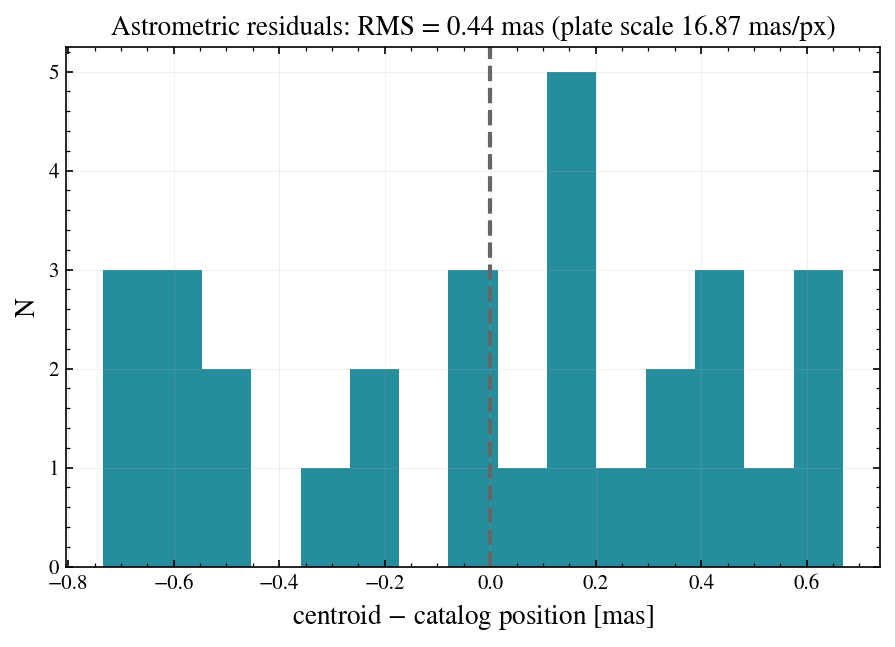

PASS: astrometric RMS 0.44 mas < 10 mas


In [7]:
from photutils.centroids import centroid_com

sel = cat[ok]
sel = sel[np.argsort(sel['phot_g_mean_mag'])][:15]     # 15 brightest isolated stars
clean = field.image_clean
h = 20
resid_mas = []
for s in sel:
    x0, y0 = int(round(s['x'])), int(round(s['y']))
    if not (h < x0 < clean.shape[1] - h and h < y0 < clean.shape[0] - h):
        continue
    cut = clean[y0 - h:y0 + h + 1, x0 - h:x0 + h + 1] - bg
    cx, cy = centroid_com(np.clip(cut, 0, None))
    resid_mas.append(((x0 - h + cx) - s['x']) * 16.87), resid_mas.append(((y0 - h + cy) - s['y']) * 16.87)

resid_mas = np.array(resid_mas)
rms = np.sqrt(np.mean(resid_mas ** 2))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(resid_mas, bins=15, color=TEAL, alpha=0.85)
ax.axvline(0, color='0.4', ls='--')
ax.set_xlabel('centroid $-$ catalog position [mas]'); ax.set_ylabel('N')
ax.set_title(f'Astrometric residuals: RMS = {rms:.2f} mas (plate scale 16.87 mas/px)')
plt.show()

assert rms < 10, f'astrometric RMS too large: {rms:.2f} mas'
print(f'PASS: astrometric RMS {rms:.2f} mas < 10 mas')

## 5. Photometric closure

Aperture photometry (r = 40 px, annulus background) on both the noiseless and the noisy image,
compared with each star's expected flux `rate_e_s × exptime` from the ETC chain. The noiseless
measurements should close to ~1% (finite-aperture wings); the noisy scatter should stay inside
the propagated noise envelope.

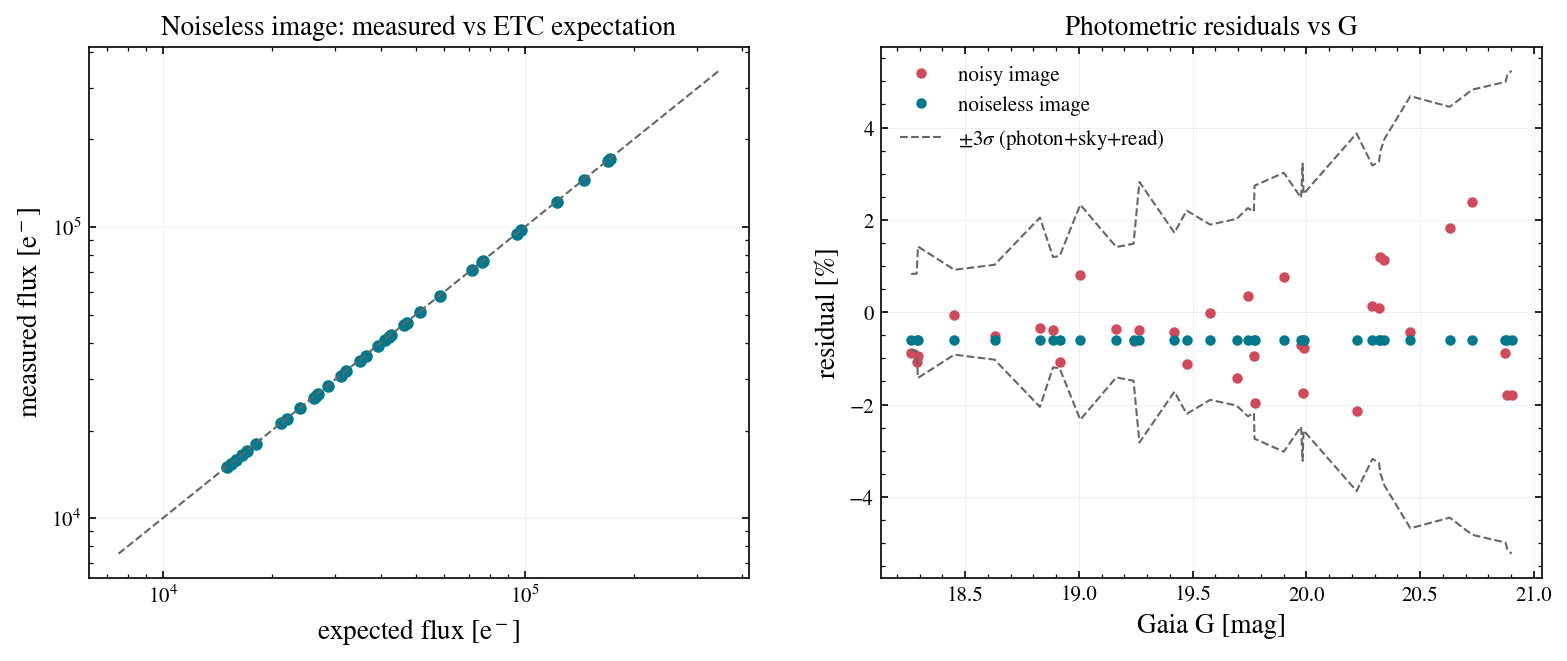

noiseless closure: median |resid| = 0.60%  (n=34)
noisy photometry: 94% of stars within 3 sigma of expectation
PASS: photometry closes on the ETC prediction


In [8]:
from photutils.aperture import CircularAnnulus, CircularAperture, aperture_photometry

R_AP, R_IN, R_OUT = 40, 60, 90
m = ok & (cat['x'] > R_OUT) & (cat['x'] < img.shape[1] - R_OUT) \
       & (cat['y'] > R_OUT) & (cat['y'] < img.shape[0] - R_OUT)
stars = cat[m]
pos = np.c_[stars['x'], stars['y']]
aper, ann = CircularAperture(pos, r=R_AP), CircularAnnulus(pos, r_in=R_IN, r_out=R_OUT)

def measure(image):
    phot = aperture_photometry(image, aper)
    bkg = aperture_photometry(image, ann)['aperture_sum'] / ann.area
    return np.asarray(phot['aperture_sum'] - bkg * aper.area)

expected = np.asarray(stars['rate_e_s']) * EXPTIME
meas_clean = measure(field.image_clean)
meas_noisy = measure(field.image_e)

resid_clean = 100 * (meas_clean - expected) / expected
resid_noisy = 100 * (meas_noisy - expected) / expected
npix = np.pi * R_AP ** 2
sigma_pct = 100 * np.sqrt(expected + npix * bg + npix * p['read_noise'] ** 2) / expected

g = np.asarray(stars['phot_g_mean_mag'])
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].loglog(expected, meas_clean, 'o', color=TEAL, ms=5)
lims = [expected.min() * 0.5, expected.max() * 2]
axes[0].plot(lims, lims, color='0.4', ls='--', lw=1)
axes[0].set_xlabel('expected flux [e$^-$]'); axes[0].set_ylabel('measured flux [e$^-$]')
axes[0].set_title('Noiseless image: measured vs ETC expectation')

order = np.argsort(g)
axes[1].plot(g, resid_noisy, 'o', color=RED, ms=4, label='noisy image')
axes[1].plot(g, resid_clean, 'o', color=TEAL, ms=4, label='noiseless image')
axes[1].plot(g[order], 3 * sigma_pct[order], color='0.4', ls='--', lw=1, label=r'$\pm3\sigma$ (photon+sky+read)')
axes[1].plot(g[order], -3 * sigma_pct[order], color='0.4', ls='--', lw=1)
axes[1].set_xlabel('Gaia G [mag]'); axes[1].set_ylabel('residual [%]')
axes[1].set_title('Photometric residuals vs G')
axes[1].legend()
plt.show()

med = np.median(np.abs(resid_clean))
frac_in = np.mean(np.abs(resid_noisy) < 3 * sigma_pct)
print(f'noiseless closure: median |resid| = {med:.2f}%  (n={len(stars)})')
print(f'noisy photometry: {100*frac_in:.0f}% of stars within 3 sigma of expectation')
assert med < 2.0, 'noiseless closure worse than 2%'
assert frac_in > 0.9, 'too many noisy measurements outside 3 sigma'
print('PASS: photometry closes on the ETC prediction')

## 6. Noise statistics

A source-free simulation should be pure sky + dark + read noise: pixel variance
= (sky+dark)·t + RN² and a near-Gaussian histogram at these count levels.

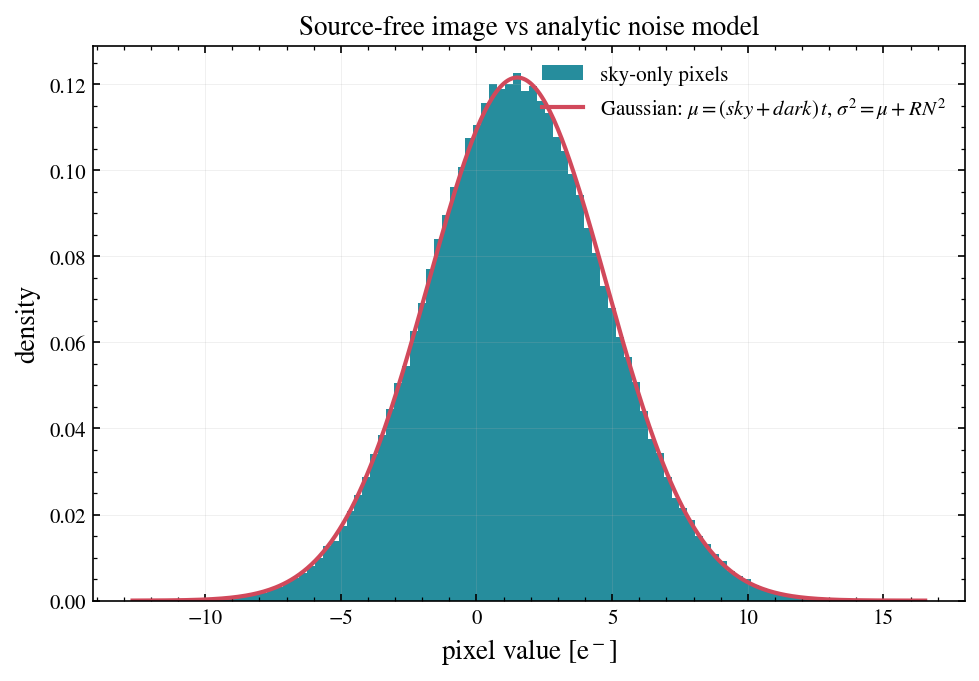

mean: measured 1.50 vs expected 1.50 e-
var : measured 10.79 vs expected 10.77 e-^2
PASS: noise statistics match (sky+dark)*t + RN^2


In [9]:
from astropy.table import Table
from wcc_sim.catalog import _empty_table

sky_field = simulate_field(ra=RA0, dec=DEC0, sensorfilter='zwo:r', focus=0,
                           exptime=EXPTIME, seed=7, shape=(512, 512),
                           catalog=_empty_table())
pix = sky_field.image_e.ravel()
lam = (p['sky_e_s'] + p['dark_e_s']) * EXPTIME
var_exp = lam + p['read_noise'] ** 2

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.hist(pix, bins=100, density=True, color=TEAL, alpha=0.85, label='sky-only pixels')
xx = np.linspace(pix.min(), pix.max(), 400)
ax.plot(xx, np.exp(-(xx - lam) ** 2 / (2 * var_exp)) / np.sqrt(2 * np.pi * var_exp),
        color=RED, label=r'Gaussian: $\mu=(sky+dark)\,t$, $\sigma^2=\mu+RN^2$')
ax.set_xlabel('pixel value [e$^-$]'); ax.set_ylabel('density')
ax.set_title('Source-free image vs analytic noise model')
ax.legend()
plt.show()

print(f'mean: measured {pix.mean():.2f} vs expected {lam:.2f} e-')
print(f'var : measured {pix.var():.2f} vs expected {var_exp:.2f} e-^2')
assert abs(pix.mean() - lam) < 0.05 * max(lam, 1), 'mean off'
assert abs(pix.var() - var_exp) < 0.10 * var_exp, 'variance off'
print('PASS: noise statistics match (sky+dark)*t + RN^2')

## 7. Saturation and FITS output

Bright stars saturate the qCMOS/CMOS wells; the pipeline flags them in the `SATMASK` extension
and per star in the catalog. The `SimulatedField` writes a multi-extension FITS
(SCI + SATMASK + CAT + CLEAN) with the WCS and every simulation parameter in the header.

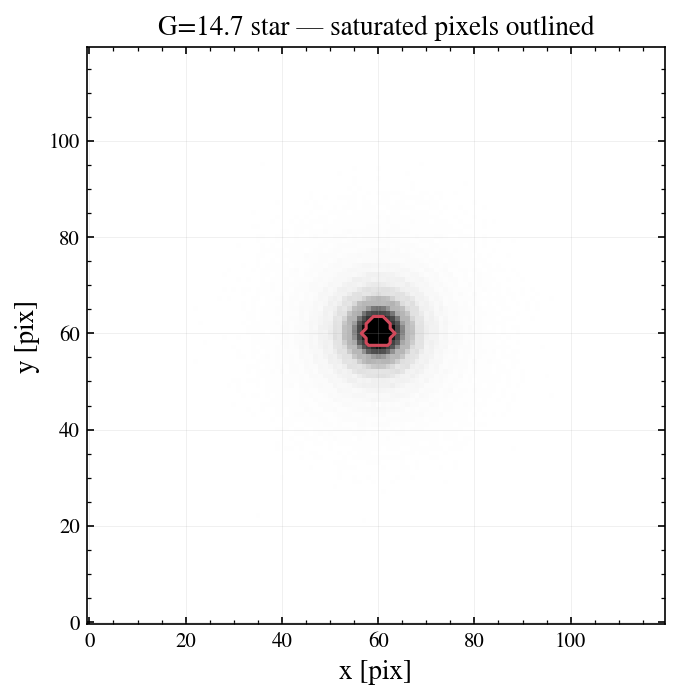

14 saturated stars in frame; brightest G=14.71


In [10]:
sat_stars = cat[np.asarray(cat['saturated'], dtype=bool) & inside]
if len(sat_stars):
    s = sat_stars[np.argmin(sat_stars['phot_g_mean_mag'])]
    x0, y0 = int(round(s['x'])), int(round(s['y']))
    h = 60
    sl = np.s_[max(y0-h,0):y0+h, max(x0-h,0):x0+h]
    fig, ax = plt.subplots(figsize=(5.8, 5))
    ax.imshow(field.image_adu[sl], origin='lower', cmap='gray_r',
              norm=simple_norm(field.image_adu[sl], 'asinh', percent=99.9))
    ax.contour(field.saturation_mask[sl], levels=[0.5], colors=[RED], linewidths=1.5)
    ax.set_title(f"G={s['phot_g_mean_mag']:.1f} star — saturated pixels outlined")
    ax.set_xlabel('x [pix]'); ax.set_ylabel('y [pix]')
    plt.show()
    print(f"{len(sat_stars)} saturated stars in frame; brightest G={s['phot_g_mean_mag']:.2f}")
else:
    print('no saturated stars in this field/exptime')

In [11]:
hdul = fields_focus[1].to_hdulist()   # the +1-wave subarray, as an example
hdul.info()
hdr = hdul['SCI'].header
keys = ['RA_PNT', 'DEC_PNT', 'SENSORF', 'FOCUS', 'EXPTIME', 'NREADS', 'JITTER',
        'PLTSCL', 'GAIN', 'RDNOISE', 'SKYRATE', 'DARK', 'WELLDEP', 'NSRC', 'WCCSIMV', 'WCCETCV']
print()
for k in keys:
    print(f'{k:8s} = {hdr[k]!r:>24}   / {hdr.comments[k]}')

fields_focus[1].write('example_field_1wave.fits')
with fits.open('example_field_1wave.fits') as f_check:
    assert [h.name for h in f_check] == ['SCI', 'SATMASK', 'CAT', 'CLEAN']
print('\nPASS: example_field_1wave.fits written and verified (SCI/SATMASK/CAT/CLEAN)')

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCI           1 PrimaryHDU      46   (600, 600)   float32   
  1  SATMASK       1 ImageHDU         8   (600, 600)   uint8   
  2  CAT           1 BinTableHDU     38   7R x 12C   ['K', 'D', 'D', 'E', 'E', 'E', 'D', 'D', '3A', 'D', 'L', 'L']   
  3  CLEAN         1 ImageHDU         9   (600, 600)   float32   



RA_PNT   =        291.0170189106795   / [deg] pointing RA (ICRS), array center
DEC_PNT  =       44.495842626555834   / [deg] pointing Dec (ICRS), array center
SENSORF  =                  'zwo:r'   / wcc_etc sensorfilter (kind:band)
FOCUS    =                        1   / [waves] defocus (0=in-focus)
EXPTIME  =                     90.0   / [s] total exposure time
NREADS   =                        1   / coadded frames (ETC semantics)
JITTER   =                     10.0   / [mas] jitter Gaussian sigma
PLTSCL   =       16.869089722675366   / [mas/pix] plate scale
GAIN     =        0.261200000004368   / [e-/ADU] sensor gain
RDNOISE  =       3.0442890448219115   / [e-] read noise per frame
SKYRATE  =     0.013643288040258746   / [e-/s/pix] sky background rate
DARK     =    0.0030703367499985944   / [e-/s/pix] dark current
WELLDEP  =       16274.929434794496   / [e-] full well (empty if None)
NSRC     =                        7   / number of injected sources
WCCSIMV  =                  '0.1.

## Summary

Verified in this notebook:

1. **Astrometry** — star centroids match the Gaia/WCS positions to a few-mas RMS.
2. **PSF modes** — in-focus Airy and the +1/+2-wave Huygens defocus PSFs render with the expected
   peak ordering and ring structure.
3. **Photometry** — aperture fluxes close on the ETC `rate × t` prediction to ≲1% (noiseless) and
   scatter within the propagated noise envelope (noisy).
4. **Noise** — source-free pixels follow mean = (sky+dark)·t and variance = mean + RN².
5. **Saturation + FITS** — bright stars flagged in SATMASK/CAT; full multi-extension FITS output.

CLI equivalent of section 1:

```bash
wcc-sim --ra 291.0 --dec 44.5 --sensorfilter zwo:r --focus 0 --exptime 90 --seed 42 -o field.fits
```